In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Установим seed для воспроизводимости
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
class SimpleNeuralNDCGLoss(nn.Module):
    """
    Простая и рабочая версия NeuralNDCG Loss
    """
    def __init__(self, temperature=0.1):
        super(SimpleNeuralNDCGLoss, self).__init__()
        self.temperature = temperature

    def forward(self, predicted_scores, true_relevances):
        """
        Args:
            predicted_scores: [batch_size, n_items] - предсказанные веса
            true_relevances: [batch_size, n_items] - истинные релевантности
        """
        batch_size, n_items = predicted_scores.shape

        # 1. Сортируем предсказанные скоры для получения "мягких" позиций
        predicted_probs = F.softmax(predicted_scores / self.temperature, dim=1)

        # 2. Вычисляем ожидаемые позиции через взвешенную сумму
        positions = torch.arange(1, n_items + 1, device=predicted_scores.device).float()
        expected_positions = torch.matmul(predicted_probs, positions)

        # 3. Идеальные позиции (сортируем по true_relevances)
        # Сначала получаем индексы сортировки по убыванию релевантности
        _, ideal_indices = torch.sort(true_relevances, descending=True, dim=1)

        # Создаем тензор для идеальных позиций
        ideal_positions = torch.zeros_like(predicted_scores)
        for i in range(batch_size):
            for j in range(n_items):
                # j-й элемент в отсортированном порядке получает позицию j+1
                ideal_positions[i, ideal_indices[i, j]] = j + 1

        # 4. Вычисляем MSE между ожидаемыми и идеальными позициями
        position_loss = F.mse_loss(expected_positions, ideal_positions.mean(dim=1))

        # 5. Дополнительно: NDCG-inspired loss
        # Преобразуем веса в "релевантности" через softmax
        pred_relevance = F.softmax(predicted_scores, dim=1)

        # Вычисляем DCG для предсказанных весов
        # Сортируем true_relevances по pred_relevance
        sorted_true_by_pred = torch.gather(true_relevances, 1,
                                          torch.argsort(pred_relevance, descending=True, dim=1))

        # Дисконтирующие коэффициенты
        discount = 1.0 / torch.log2(torch.arange(2, n_items + 2,
                                                device=predicted_scores.device).float())

        dcg = torch.sum((2.0**sorted_true_by_pred - 1) * discount, dim=1)

        # Идеальный DCG (сортировка по true_relevances)
        sorted_true_ideal, _ = torch.sort(true_relevances, descending=True, dim=1)
        ideal_dcg = torch.sum((2.0**sorted_true_ideal - 1) * discount, dim=1)

        # NDCG
        ndcg = dcg / (ideal_dcg + 1e-10)
        ndcg_loss = 1.0 - ndcg.mean()

        # Комбинируем losses
        total_loss = position_loss + ndcg_loss

        return total_loss

In [3]:
class FixedSRR(nn.Module):
    """
    Исправленная версия Semantic Relational Reasoning
    """
    def __init__(self, feature_dim=768, num_classes=30):
        super(FixedSRR, self).__init__()

        # Unified weight network
        self.weight_network = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1)
        )

        # Классификатор с правильными размерами
        # Вход: 3 * feature_dim (F_T + weighted_sum из enhanced_features)
        self.classifier = nn.Sequential(
            nn.Linear(3 * feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_classes)
        )

    def forward(self, F_T, F_A, F_E, F_I, relevances=None, use_ndcg=False):
        batch_size = F_T.shape[0]

        # 1. Relative Importance
        features = [F_T, F_A, F_E, F_I]
        weights = []

        for feat in features:
            weight = self.weight_network(feat)
            weights.append(weight)

        weights = torch.cat(weights, dim=1)  # [batch, 4]
        importance_weights = F.softmax(weights, dim=1)

        # NeuralNDCG loss если нужно
        ndcg_loss = torch.tensor(0.0).to(F_T.device)
        if use_ndcg and relevances is not None:
            ndcg_criterion = SimpleNeuralNDCGLoss(temperature=0.1)
            ndcg_loss = ndcg_criterion(importance_weights, relevances)

        # 2. Complementarity
        complementarity_scores = []
        for feat in [F_A, F_E, F_I]:
            # Нормализуем признаки для вычисления косинусного сходства
            F_T_norm = F.normalize(F_T, dim=1)
            feat_norm = F.normalize(feat, dim=1)
            score = torch.sum(F_T_norm * feat_norm, dim=1).unsqueeze(1)  # [batch, 1]
            complementarity_scores.append(score)

        # 3. Усиление признаков комплементарностью
        enhanced_features = []
        for i, (feat, comp_score) in enumerate(zip([F_A, F_E, F_I], complementarity_scores)):
            enhanced = comp_score * feat
            # Конкатенируем с текстовым признаком
            combined = torch.cat([F_T, enhanced], dim=1)  # [batch, 2*feature_dim]
            enhanced_features.append(combined)

        # 4. Взвешенная сумма enhanced_features
        weighted_sum = torch.zeros(batch_size, 2 * F_T.shape[1]).to(F_T.device)
        for i in range(3):
            # Используем веса для A, E, I (пропускаем вес для текста)
            weight = importance_weights[:, i+1:i+2]  # [batch, 1]
            weighted_sum += weight * enhanced_features[i]

        # 5. Final feature (текст + взвешенная сумма)
        final_feature = torch.cat([F_T, weighted_sum], dim=1)  # [batch, 3*feature_dim]

        # 6. Classification
        logits = self.classifier(final_feature)

        return logits, importance_weights, ndcg_loss

In [4]:
class FixedLGSRR(nn.Module):
    """
    Исправленная модель LGSRR
    """
    def __init__(self, input_dim=768, num_classes=30):
        super(FixedLGSRR, self).__init__()

        # SRR модуль
        self.srr = FixedSRR(feature_dim=input_dim, num_classes=num_classes)

    def forward(self, features, relevances=None, use_ndcg=True):
        """
        Args:
            features: [batch, 4, input_dim] - признаки
            relevances: [batch, 4] - релевантности
        """
        # Разделяем признаки
        F_T = features[:, 0, :]  # Текст
        F_A = features[:, 1, :]  # Действия
        F_E = features[:, 2, :]  # Выражения
        F_I = features[:, 3, :]  # Взаимодействия

        # Semantic Relational Reasoning
        logits, importance_weights, ndcg_loss = self.srr(
            F_T, F_A, F_E, F_I, relevances, use_ndcg
        )

        return logits, importance_weights, ndcg_loss

In [5]:
class FixedDataset(Dataset):
    """Исправленный датасет"""
    def __init__(self, num_samples=1000, feature_dim=768, num_classes=30, is_train=True):
        self.num_samples = num_samples
        self.feature_dim = feature_dim
        self.num_classes = num_classes

        # Генерируем случайные признаки
        self.features = torch.randn(num_samples, 4, feature_dim)

        # Релевантности: текст всегда самый важный (3), остальные 0-2
        self.relevances = torch.zeros(num_samples, 4)
        for i in range(num_samples):
            # Текст всегда имеет высшую релевантность
            self.relevances[i, 0] = 3.0
            # Остальные случайно
            other_ranks = torch.randperm(3)
            self.relevances[i, 1:] = other_ranks.float()

        # Метки классов
        if is_train:
            self.labels = torch.randint(0, num_classes, (num_samples,))
        else:
            # Немного смещенное распределение для валидации
            probs = torch.ones(num_classes)
            probs[:num_classes//3] = 2.0
            probs = probs / probs.sum()
            self.labels = torch.multinomial(probs, num_samples, replacement=True)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return {
            'features': self.features[idx],
            'relevances': self.relevances[idx],
            'label': self.labels[idx]
        }

In [6]:
def train_fixed_model(model, train_loader, val_loader, epochs=5,
                      use_ndcg=True, lambda_rank=0.3, device='cpu'):
    """Обучение модели (исправленная версия)"""

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion_cls = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # Тренировка
        model.train()
        epoch_loss, correct, total = 0, 0, 0

        for batch_idx, batch in enumerate(train_loader):
            features = batch['features'].to(device)
            relevances = batch['relevances'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()

            logits, _, ndcg_loss = model(features, relevances, use_ndcg)

            # Классификационный loss
            cls_loss = criterion_cls(logits, labels)

            # Общий loss
            if use_ndcg:
                total_loss = cls_loss + lambda_rank * ndcg_loss
            else:
                total_loss = cls_loss

            total_loss.backward()
            optimizer.step()

            epoch_loss += total_loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Валидация
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                features = batch['features'].to(device)
                relevances = batch['relevances'].to(device)
                labels = batch['label'].to(device)

                logits, _, ndcg_loss = model(features, relevances, use_ndcg)

                cls_loss = criterion_cls(logits, labels)

                if use_ndcg:
                    total_loss = cls_loss + lambda_rank * ndcg_loss
                else:
                    total_loss = cls_loss

                val_loss += total_loss.item()
                _, predicted = torch.max(logits, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        if use_ndcg and epoch == 0:
            print(f'  Initial NDCG Loss: {ndcg_loss.item():.4f}')
        print('-' * 40)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

In [7]:
# Создаем датасеты
train_dataset = FixedDataset(num_samples=800, feature_dim=768, num_classes=30, is_train=True)
val_dataset = FixedDataset(num_samples=200, feature_dim=768, num_classes=30, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}")

# Эксперимент 1: С NeuralNDCG
print("\n" + "="*50)
print("ЭКСПЕРИМЕНТ 1: LGSRR с NeuralNDCG")
print("="*50)
model_ndcg = FixedLGSRR(input_dim=768, num_classes=30).to(device)
print(f"Параметры модели: {sum(p.numel() for p in model_ndcg.parameters()):,}")

# Проверяем forward pass
print("\nТестирование forward pass...")
test_batch = next(iter(train_loader))
features_test = test_batch['features'].to(device)[:2]  # Берем 2 примера
relevances_test = test_batch['relevances'].to(device)[:2]

try:
    with torch.no_grad():
        logits, weights, ndcg_loss = model_ndcg(features_test, relevances_test, use_ndcg=True)
        print(f"✓ Forward pass успешен!")
        print(f"  Logits shape: {logits.shape}")
        print(f"  Weights shape: {weights.shape}")
        print(f"  NDCG loss: {ndcg_loss.item():.4f}")
except Exception as e:
    print(f"✗ Ошибка в forward pass: {e}")
    import traceback
    traceback.print_exc()

# Запускаем обучение
print("\nНачинаем обучение...")
results_ndcg = train_fixed_model(
    model_ndcg, train_loader, val_loader,
    epochs=5, use_ndcg=True, lambda_rank=0.3, device=device
)

# Эксперимент 2: Без NeuralNDCG
print("\n" + "="*50)
print("ЭКСПЕРИМЕНТ 2: LGSRR без NeuralNDCG")
print("="*50)
model_no_ndcg = FixedLGSRR(input_dim=768, num_classes=30).to(device)

print("\nНачинаем обучение...")
results_no_ndcg = train_fixed_model(
    model_no_ndcg, train_loader, val_loader,
    epochs=5, use_ndcg=False, device=device
)

Dataset sizes: Train=800, Val=200

ЭКСПЕРИМЕНТ 1: LGSRR с NeuralNDCG
Параметры модели: 1,392,671

Тестирование forward pass...
✓ Forward pass успешен!
  Logits shape: torch.Size([2, 30])
  Weights shape: torch.Size([2, 4])
  NDCG loss: 0.1458

Начинаем обучение...
Epoch 1/5:
  Train Loss: 3.5826, Train Acc: 0.0312
  Val Loss: 3.6252, Val Acc: 0.0300
  Initial NDCG Loss: 0.2568
----------------------------------------
Epoch 2/5:
  Train Loss: 1.2089, Train Acc: 0.9875
  Val Loss: 3.8276, Val Acc: 0.0350
----------------------------------------
Epoch 3/5:
  Train Loss: 0.2000, Train Acc: 1.0000
  Val Loss: 3.9905, Val Acc: 0.0200
----------------------------------------
Epoch 4/5:
  Train Loss: 0.1355, Train Acc: 1.0000
  Val Loss: 4.0600, Val Acc: 0.0200
----------------------------------------
Epoch 5/5:
  Train Loss: 0.1244, Train Acc: 1.0000
  Val Loss: 4.1103, Val Acc: 0.0200
----------------------------------------

ЭКСПЕРИМЕНТ 2: LGSRR без NeuralNDCG

Начинаем обучение...
Epoch 1/

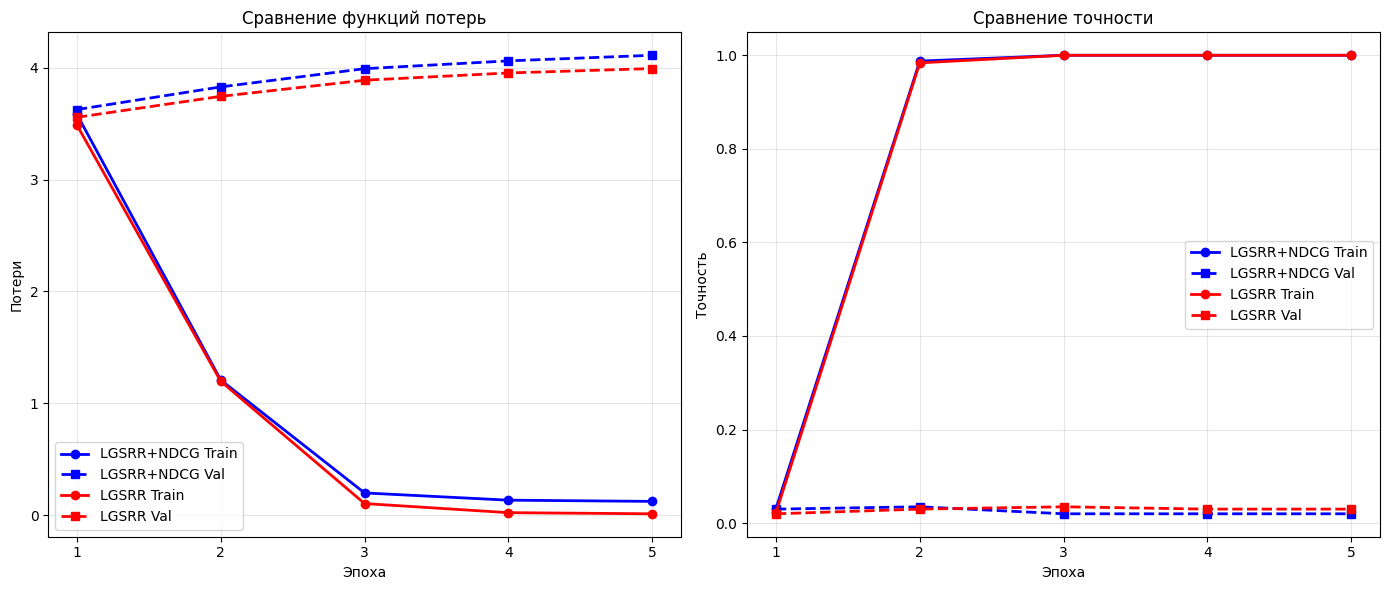


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
         Метрика С NeuralNDCG Без NeuralNDCG Разница
Final Train Loss       0.1244         0.0137 +0.1108
  Final Val Loss       4.1103         3.9917 +0.1187
 Final Train Acc       1.0000         1.0000 +0.0000
   Final Val Acc       0.0200         0.0300 -0.0100

АНАЛИЗ ВЕСОВ ВАЖНОСТИ

Модель с NeuralNDCG:
Средние веса важности:
  Текст: 0.2499 ± 0.0110
  Действия: 0.2498 ± 0.0113
  Выражения: 0.2501 ± 0.0117
  Взаимодействия: 0.2502 ± 0.0114

Модель без NeuralNDCG:
Средние веса важности:
  Текст: 0.2610 ± 0.1317
  Действия: 0.2346 ± 0.1214
  Выражения: 0.2631 ± 0.1477
  Взаимодействия: 0.2412 ± 0.1247


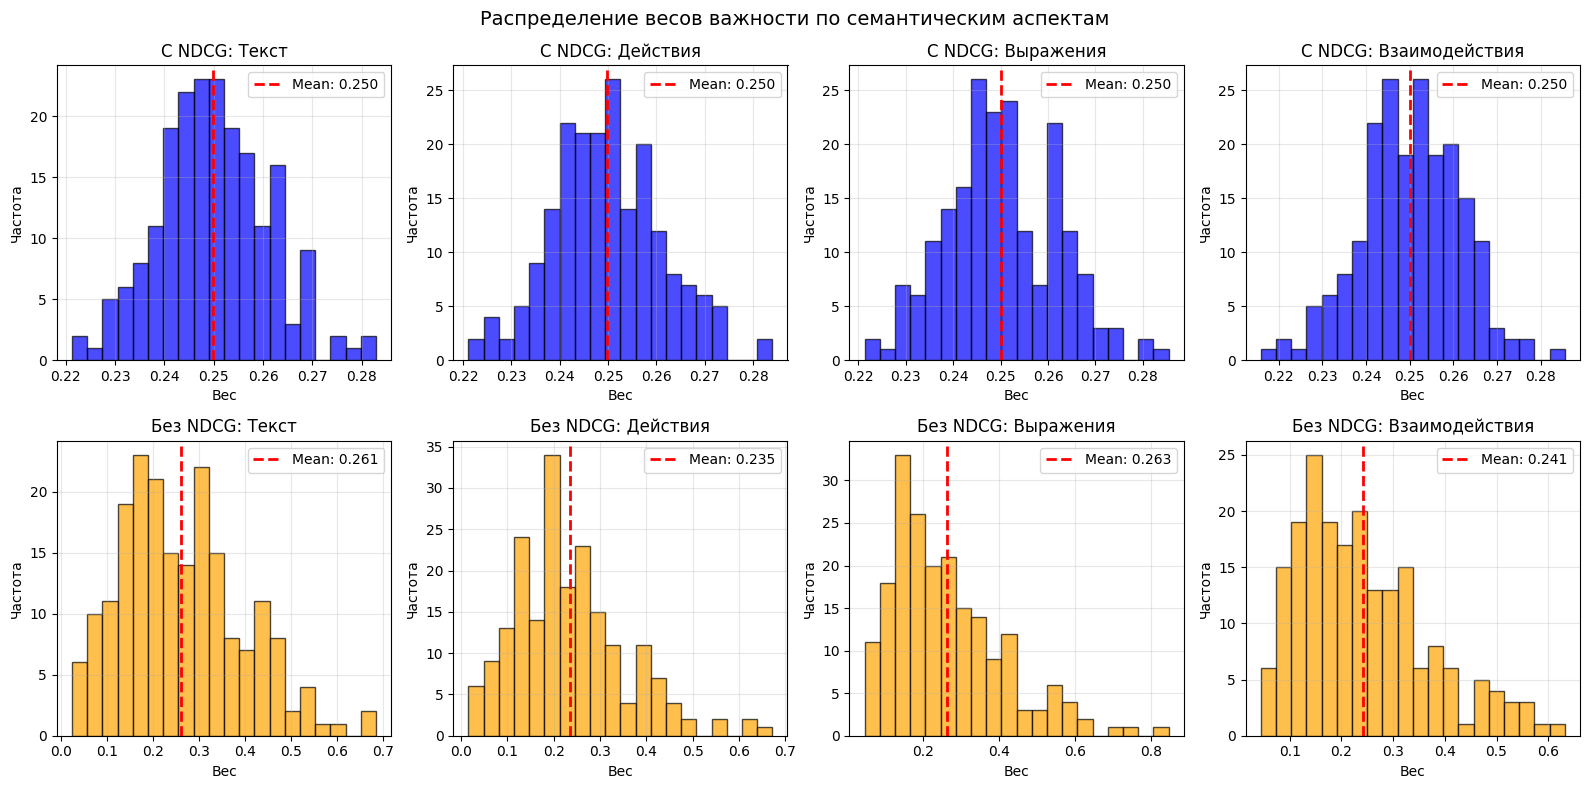

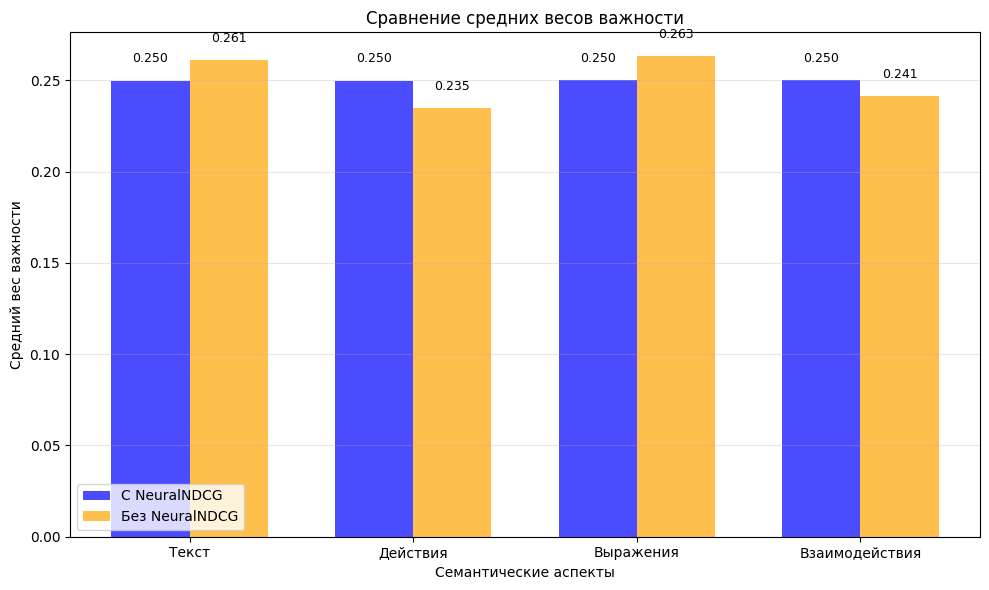

In [8]:
# Проверяем, что эксперименты завершились
if 'results_ndcg' in locals() and 'results_no_ndcg' in locals():
    # Графики обучения
    plt.figure(figsize=(14, 6))

    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(results_ndcg['train_losses'], 'b-o', label='LGSRR+NDCG Train', linewidth=2, markersize=6)
    plt.plot(results_ndcg['val_losses'], 'b--s', label='LGSRR+NDCG Val', linewidth=2, markersize=6)
    plt.plot(results_no_ndcg['train_losses'], 'r-o', label='LGSRR Train', linewidth=2, markersize=6)
    plt.plot(results_no_ndcg['val_losses'], 'r--s', label='LGSRR Val', linewidth=2, markersize=6)
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.title('Сравнение функций потерь')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(len(results_ndcg['train_losses'])), range(1, len(results_ndcg['train_losses']) + 1))

    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(results_ndcg['train_accs'], 'b-o', label='LGSRR+NDCG Train', linewidth=2, markersize=6)
    plt.plot(results_ndcg['val_accs'], 'b--s', label='LGSRR+NDCG Val', linewidth=2, markersize=6)
    plt.plot(results_no_ndcg['train_accs'], 'r-o', label='LGSRR Train', linewidth=2, markersize=6)
    plt.plot(results_no_ndcg['val_accs'], 'r--s', label='LGSRR Val', linewidth=2, markersize=6)
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.title('Сравнение точности')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(len(results_ndcg['train_accs'])), range(1, len(results_ndcg['train_accs']) + 1))

    plt.tight_layout()
    plt.show()

    # Сводная таблица
    results_summary = pd.DataFrame({
        'Метрика': ['Final Train Loss', 'Final Val Loss', 'Final Train Acc', 'Final Val Acc'],
        'С NeuralNDCG': [
            f"{results_ndcg['train_losses'][-1]:.4f}",
            f"{results_ndcg['val_losses'][-1]:.4f}",
            f"{results_ndcg['train_accs'][-1]:.4f}",
            f"{results_ndcg['val_accs'][-1]:.4f}"
        ],
        'Без NeuralNDCG': [
            f"{results_no_ndcg['train_losses'][-1]:.4f}",
            f"{results_no_ndcg['val_losses'][-1]:.4f}",
            f"{results_no_ndcg['train_accs'][-1]:.4f}",
            f"{results_no_ndcg['val_accs'][-1]:.4f}"
        ],
        'Разница': [
            f"{results_ndcg['train_losses'][-1] - results_no_ndcg['train_losses'][-1]:+.4f}",
            f"{results_ndcg['val_losses'][-1] - results_no_ndcg['val_losses'][-1]:+.4f}",
            f"{results_ndcg['train_accs'][-1] - results_no_ndcg['train_accs'][-1]:+.4f}",
            f"{results_ndcg['val_accs'][-1] - results_no_ndcg['val_accs'][-1]:+.4f}"
        ]
    })

    print("\n" + "="*60)
    print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    print("="*60)
    print(results_summary.to_string(index=False))

    # Анализ весов важности
    print("\n" + "="*60)
    print("АНАЛИЗ ВЕСОВ ВАЖНОСТИ")
    print("="*60)

    def analyze_model_weights(model, dataloader, device, model_name):
        """Анализ весов модели"""
        model.eval()
        all_weights = []

        with torch.no_grad():
            for batch in dataloader:
                features = batch['features'].to(device)
                relevances = batch['relevances'].to(device)

                _, importance_weights, _ = model(features, relevances, use_ndcg=True)
                all_weights.append(importance_weights.cpu())

        if all_weights:
            all_weights = torch.cat(all_weights, dim=0)

            print(f"\n{model_name}:")
            print("Средние веса важности:")
            aspects = ['Текст', 'Действия', 'Выражения', 'Взаимодействия']
            for i, aspect in enumerate(aspects):
                mean_weight = all_weights[:, i].mean().item()
                std_weight = all_weights[:, i].std().item()
                print(f"  {aspect}: {mean_weight:.4f} ± {std_weight:.4f}")

            return all_weights
        return None

    weights_ndcg = analyze_model_weights(model_ndcg, val_loader, device, "Модель с NeuralNDCG")
    weights_no_ndcg = analyze_model_weights(model_no_ndcg, val_loader, device, "Модель без NeuralNDCG")

    if weights_ndcg is not None and weights_no_ndcg is not None:
        # Визуализация распределения весов
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        aspects = ['Текст', 'Действия', 'Выражения', 'Взаимодействия']

        for i, aspect in enumerate(aspects):
            # С NeuralNDCG
            ax1 = axes[0, i]
            ax1.hist(weights_ndcg[:, i].numpy(), bins=20, alpha=0.7, color='blue', edgecolor='black')
            ax1.set_title(f'С NDCG: {aspect}')
            ax1.set_xlabel('Вес')
            ax1.set_ylabel('Частота')
            ax1.axvline(weights_ndcg[:, i].mean().item(), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {weights_ndcg[:, i].mean():.3f}')
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            # Без NeuralNDCG
            ax2 = axes[1, i]
            ax2.hist(weights_no_ndcg[:, i].numpy(), bins=20, alpha=0.7, color='orange', edgecolor='black')
            ax2.set_title(f'Без NDCG: {aspect}')
            ax2.set_xlabel('Вес')
            ax2.set_ylabel('Частота')
            ax2.axvline(weights_no_ndcg[:, i].mean().item(), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {weights_no_ndcg[:, i].mean():.3f}')
            ax2.legend()
            ax2.grid(True, alpha=0.3)

        plt.suptitle('Распределение весов важности по семантическим аспектам', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Сравнительная визуализация средних весов
        plt.figure(figsize=(10, 6))
        x = np.arange(4)
        width = 0.35

        mean_ndcg = weights_ndcg.mean(dim=0).numpy()
        mean_no_ndcg = weights_no_ndcg.mean(dim=0).numpy()

        plt.bar(x - width/2, mean_ndcg, width, label='С NeuralNDCG', color='blue', alpha=0.7)
        plt.bar(x + width/2, mean_no_ndcg, width, label='Без NeuralNDCG', color='orange', alpha=0.7)

        plt.xlabel('Семантические аспекты')
        plt.ylabel('Средний вес важности')
        plt.title('Сравнение средних весов важности')
        plt.xticks(x, aspects)
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')

        # Добавляем значения на столбцы
        for i, v in enumerate(mean_ndcg):
            plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
        for i, v in enumerate(mean_no_ndcg):
            plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

        plt.tight_layout()
        plt.show()

else:
    print("Ошибка: эксперименты не были завершены успешно!")


КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

Корреляция между предсказанными весами и истинными релевантностями:
Аспект		С NDCG		Без NDCG	Разница (NDCG - NoNDCG)
----------------------------------------------------------------------
Текст		0.0000		0.0000		+0.0000
Действия		0.0155		-0.0522		+0.0677
Выражения		0.0127		-0.1331		+0.1458
Взаимодействия		0.0660		-0.1130		+0.1791


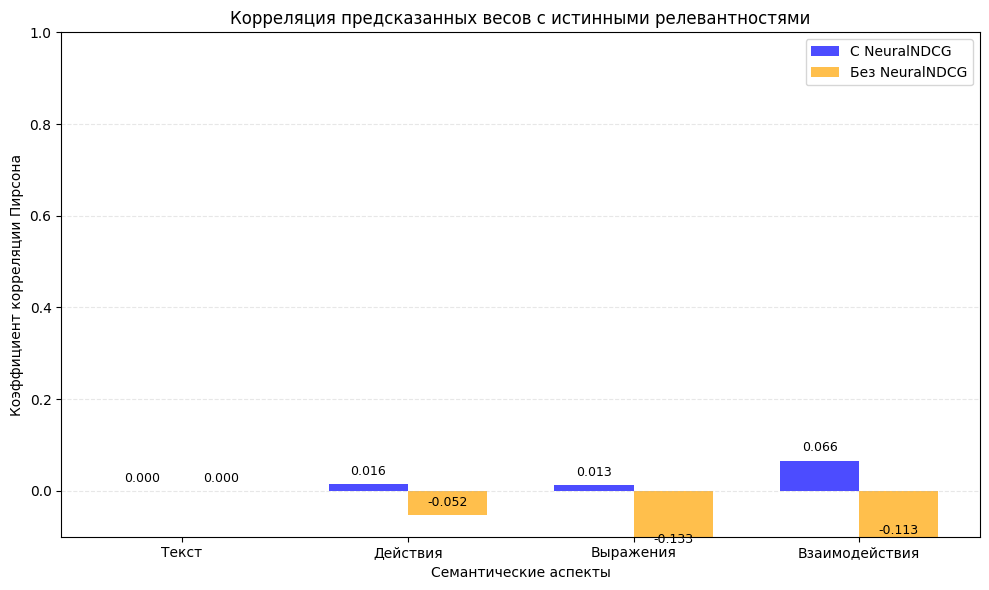


Precision@3 (способность находить правильный класс в топ-3 предсказаниях):
  С NeuralNDCG:    0.1000
  Без NeuralNDCG:  0.1050
  Улучшение:       -0.0050


In [9]:
def calculate_correlations(model, dataloader, device):
    """Вычисление корреляции между предсказанными весами и истинными релевантностями"""
    model.eval()
    all_pred_weights = []
    all_true_relevances = []

    with torch.no_grad():
        for batch in dataloader:
            features = batch['features'].to(device)
            relevances = batch['relevances'].to(device)

            _, importance_weights, _ = model(features, relevances, use_ndcg=True)

            all_pred_weights.append(importance_weights.cpu())
            all_true_relevances.append(relevances.cpu())

    if not all_pred_weights:
        return None, None, None

    all_pred_weights = torch.cat(all_pred_weights, dim=0)
    all_true_relevances = torch.cat(all_true_relevances, dim=0)

    # Вычисляем корреляцию для каждого аспекта
    correlations = []
    for i in range(4):
        pred = all_pred_weights[:, i].numpy()
        true = all_true_relevances[:, i].numpy()

        # Коэффициент корреляции Пирсона
        correlation_matrix = np.corrcoef(pred, true)
        correlation = correlation_matrix[0, 1]

        # Если значение NaN (например, если все значения одинаковые), заменяем на 0
        if np.isnan(correlation):
            correlation = 0.0

        correlations.append(correlation)

    return correlations, all_pred_weights, all_true_relevances

print("\n" + "="*60)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*60)

# Для модели с NeuralNDCG
corr_ndcg, pred_ndcg, true_ndcg = calculate_correlations(model_ndcg, val_loader, device)

# Для модели без NeuralNDCG
corr_no_ndcg, pred_no_ndcg, true_no_ndcg = calculate_correlations(model_no_ndcg, val_loader, device)

if corr_ndcg is not None and corr_no_ndcg is not None:
    print("\nКорреляция между предсказанными весами и истинными релевантностями:")
    print("Аспект\t\tС NDCG\t\tБез NDCG\tРазница (NDCG - NoNDCG)")
    print("-" * 70)
    aspects = ['Текст', 'Действия', 'Выражения', 'Взаимодействия']
    for i, aspect in enumerate(aspects):
        diff = corr_ndcg[i] - corr_no_ndcg[i]
        print(f"{aspect}\t\t{corr_ndcg[i]:.4f}\t\t{corr_no_ndcg[i]:.4f}\t\t{diff:+.4f}")

    # Визуализация корреляций
    plt.figure(figsize=(10, 6))
    x = np.arange(4)
    width = 0.35

    plt.bar(x - width/2, corr_ndcg, width, label='С NeuralNDCG', color='blue', alpha=0.7)
    plt.bar(x + width/2, corr_no_ndcg, width, label='Без NeuralNDCG', color='orange', alpha=0.7)

    plt.xlabel('Семантические аспекты')
    plt.ylabel('Коэффициент корреляции Пирсона')
    plt.title('Корреляция предсказанных весов с истинными релевантностями')
    plt.xticks(x, aspects)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--', axis='y')
    plt.ylim(-0.1, 1.0)

    # Добавляем значения на столбцы
    for i, v in enumerate(corr_ndcg):
        plt.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
    for i, v in enumerate(corr_no_ndcg):
        plt.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Precision@K анализ
    def calculate_precision_at_k(model, dataloader, k=3, device='cpu'):
        """Вычисление Precision@K"""
        model.eval()
        topk_correct = 0
        total = 0

        with torch.no_grad():
            for batch in dataloader:
                features = batch['features'].to(device)
                relevances = batch['relevances'].to(device)
                labels = batch['label'].to(device)

                logits, _, _ = model(features, relevances, use_ndcg=True)

                # Получаем топ-k предсказаний
                topk_preds = torch.topk(logits, k=k, dim=1)[1]

                # Проверяем, есть ли правильный класс в топ-k
                for i in range(len(labels)):
                    if labels[i] in topk_preds[i]:
                        topk_correct += 1
                    total += 1

        return topk_correct / total if total > 0 else 0.0

    precision_ndcg = calculate_precision_at_k(model_ndcg, val_loader, k=3, device=device)
    precision_no_ndcg = calculate_precision_at_k(model_no_ndcg, val_loader, k=3, device=device)

    print(f"\nPrecision@3 (способность находить правильный класс в топ-3 предсказаниях):")
    print(f"  С NeuralNDCG:    {precision_ndcg:.4f}")
    print(f"  Без NeuralNDCG:  {precision_no_ndcg:.4f}")
    print(f"  Улучшение:       {precision_ndcg - precision_no_ndcg:+.4f}")

else:
    print("Не удалось вычислить корреляции!")